# Evaluación 2 — Reconstrucción con red neuronal y capa de Fourier
**Programación Científica 2026-1 · Universidad Nacional de Colombia**

**Estudiante:** Juan Camilo Castaño Chavarriaga

**Cédula:** 1034991170

---

## Pregunta guía
> ¿Conviene inicializar la primera capa de la red en la **base de Fourier** en lugar de una **base aleatoria** para reconstruir señales de un medio dispersivo?

Aquí crearemos una red $\hat x = W_2\,\tanh(W_1 x)$ con $x\in\mathbb{R}^{256}$, $K=15$ frecuencias, y la entrenaremos sobre los **tres regímenes** del medio ($\mu\in\{0,5,15\}$) con las **dos inicializaciones de $W_1$**, compararemos sus resultados, analizaremos la utilidad de las distintas inicializaciones y además llevaremos a cabo un experimento adicional nacido de querer entender la interacción de una red neuronal y los conceptos relacionados a la transformada de Fourier discreta.

## 0. Imports y estilo del proyecto

Importación de librerías, establecimiento de semilla global y definición de estilo único para las gráficas.

In [56]:
# ============================================================
#  IMPORTS Y CONFIGURACIÓN GLOBAL
# ============================================================
import numpy as np                     # cálculo numérico en CPU
import matplotlib.pyplot as plt         # figuras
import jax                              # autodiferenciación + JIT (el "motor" de la red)
import jax.numpy as jnp                 # versión de numpy que JAX sabe derivar
from jax import grad, jit, vmap, value_and_grad, random

# JAX usa float32 por defecto; lo subimos a float64 para tener precisión de "máquina"
# (importante para verificar identidades como W1 x == DFT o Parseval).
jax.config.update("jax_enable_x64", True)

SEMILLA = 1170                          # semilla global (coincide con el ID del enunciado)

# ============================================================
#  ESTILO DEL PROYECTO
# ============================================================
plt.rcParams.update({
    # --- fuente tipo LaTeX ---
    "text.usetex":         True,
    "font.family":         "serif",
    "font.serif":          ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
    "font.size":           16,

    # --- ejes y ticks ---
    "axes.labelsize":      16,
    "axes.titlesize":      18,
    "xtick.labelsize":     14,
    "ytick.labelsize":     14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction":     "in",
    "ytick.direction":     "in",

    # --- rejilla ---
    "axes.grid":           True,   # rejilla activa por defecto (se apaga con ax.grid(False))
    "grid.color":          "gray",
    "grid.linewidth":      0.3,
    "grid.alpha":          0.3,
    "grid.linestyle":      "--",

    # --- estética ---
    "figure.dpi":          120,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "savefig.bbox":        "tight",
    "savefig.dpi":         300,
})


# Paleta CUALITATIVA por régimen con tres categorías bien separadas
COLOR_REG = {0: "#1b6ca8", 1: "#e08b00", 2: "#b8002b"}

NOMBRE_REG = {0: r"Régimen 0 — sin dispersión ($\mu=0$)",
              1: r"Régimen 1 — intermedia ($\mu=5$)",
              2: r"Régimen 2 — fuerte ($\mu=15$)"}

COLOR_FOURIER = "#1b6ca8"   # trazo principal (para inicialización Fourier)

COLOR_RANDOM  = "0.55"      # gris: base de comparación (para inicialización aleatoria)

CMAP_SECUENCIAL = "viridis" # colormap para datos escalares (de bajo a alto)




def barra_color(fig, mappable, ax, etiqueta):

    """Añade una colorbar con proporciones uniformes en todo el proyecto."""

    cb = fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(etiqueta)
    return cb




def dibujar_original(ax, tiempo, senal, color="k", label="original (interpolada)"):

    """Dibuja la señal original dentro de una comparación:
    interpolación continua + puntos de muestra (mismo color, un poco más grandes,
    siempre al fondo con zorder bajo) para que la reconstrucción se pinte encima."""

    ax.plot(tiempo, senal, marker="o", linestyle="-", color=color, lw=1.3,
            markersize=4.5, zorder=1, label=label)

print("JAX:", jax.__version__, "| backend:", jax.default_backend())
print("Estilo tipo LaTeX (Computer Modern) activo — igual que el notebook de referencia")


JAX: 0.10.2 | backend: cpu
Estilo tipo LaTeX (Computer Modern) activo — igual que el notebook de referencia


# Parte I — Los datos

## 1.1 Carga e inspección
Cada señal tiene 256 muestras en $t\in[0,1)$ s. Hay 8 señales por régimen (24 en total).

Inspección del archivo `datos_1170.npz`, carga y extracción de los tres arrays (`senales`, `regimenes`, `tiempo`), cálculo de parámetros de muestreo (paso temporal, frecuencia de muestreo y frecuencia de Nyquist) e impresión de resumen para confirmar las dimensiones.

### Estructura interna del archivo `.npz`

Visualización de los contenidos del archivo, donde se encuentran almacenadas las señales a analizar.

In [57]:
import pandas as pd
from IPython.display import display, Markdown

pd.set_option("styler.render.max_columns", 8)   # resume las 256 columnas con "…"

# Visualización de los datos como una tabla, donde cada fila corresponde a una señal y cada columna a un instante de tiempo. La primera columna es la etiqueta del régimen.
columnas_tiempo = [f"t={ti:.3f}" for ti in tiempo]     # nombre de cada columna = instante de tiempo
tabla_datos = pd.DataFrame(senales, columns=columnas_tiempo)
tabla_datos.insert(0, "régimen", regimenes)            # etiqueta como primera columna
tabla_datos.index.name = "señal #"

def _color_regimen(valor):
    # colorea la celda de 'régimen' con la paleta del proyecto
    return f"background-color: {COLOR_REG[valor]}; color: white; font-weight: bold"

tabla_estilizada = (tabla_datos.style
    .map(_color_regimen, subset=["régimen"])
    .format("{:.3f}", subset=columnas_tiempo))
display(tabla_estilizada)


,régimen,t=0.000,t=0.004,t=0.008,t=0.012,t=0.016,t=0.020,t=0.023,...
señal #,,,,,,,,,
0,0,1.134,1.340,1.507,1.707,1.815,1.902,1.934,...
1,2,0.141,-0.054,-0.140,-0.175,-0.168,-0.076,-0.029,...
2,1,0.750,0.768,0.725,0.691,0.650,0.538,0.446,...
3,0,-1.048,-0.941,-0.832,-0.691,-0.524,-0.395,-0.232,...
4,0,-0.835,-0.957,-1.123,-1.196,-1.227,-1.235,-1.193,...
5,1,-0.148,0.038,0.260,0.479,0.701,0.879,1.072,...
6,0,0.267,0.374,0.457,0.558,0.658,0.690,0.744,...
7,1,-0.612,-0.802,-0.985,-1.093,-1.133,-1.110,-1.010,...
8,2,0.803,1.001,0.969,0.836,0.585,0.239,-0.183,...


### Carga y extracción de la información


In [58]:
# Cargamos el contenedor .npz (varios arrays con nombre dentro de un solo archivo)
datos = np.load("datos_1170.npz")

senales   = datos["X"].astype(np.float64)   # (24, 256): 24 señales, cada una de 256 muestras
regimenes = datos["y"].astype(np.int64)     # (24,)   : régimen (0, 1 o 2) de cada señal
tiempo    = datos["t"].astype(np.float64)   # (256,)  : instantes de muestreo, compartidos

# Parámetros de muestreo (derivados del eje de tiempo)
n_muestras     = senales.shape[1]               # 256 muestras por señal
paso_temporal  = float(tiempo[1] - tiempo[0])   # Δt entre muestras [s]
frec_muestreo  = 1.0 / paso_temporal            # fs = 1/Δt [Hz]

# Resumen de dimensiones y muestreo
print(f"senales: {senales.shape}  ·  regimenes: {regimenes.shape}  ·  tiempo: {tiempo.shape}")
print(f"Δt = {paso_temporal:.5f} s  ->  fs = {frec_muestreo:.1f} Hz   "
      f"(Nyquist = {frec_muestreo/2:.1f} Hz)")
for r in (0, 1, 2):
    print(f"  régimen {r}: {(regimenes == r).sum()} señales")

senales: (24, 256)  ·  regimenes: (24,)  ·  tiempo: (256,)
Δt = 0.00391 s  ->  fs = 256.0 Hz   (Nyquist = 128.0 Hz)
  régimen 0: 8 señales
  régimen 1: 8 señales
  régimen 2: 8 señales


## 1.2 Visualización de señales por régimen

Para entender mejor los datos con los que estamos trabajando, se muestra la primera señal de cada régimen y se establece el código de colores que caracterizará nuestro análisis: 
Azul para **régimen 0**, sin dispersión; naranja para **régimen 1**, con dispersión intermedia; rojo para **régimen 2**, con dispesión fuerte. 

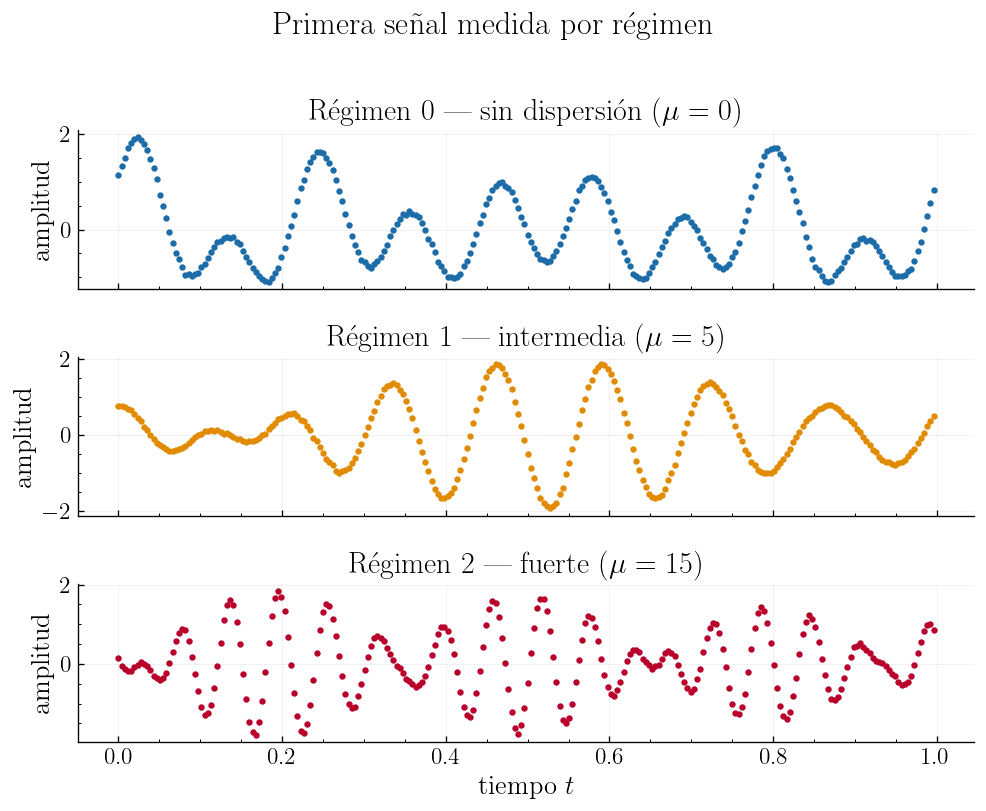

In [59]:
# Un panel por régimen: mostramos la PRIMERA señal de cada uno como muestras discretas
fig, axes = plt.subplots(3, 1, figsize=(8.5, 6.8), sharex=True)

for ax, reg in zip(axes, (0, 1, 2)):
    indice = np.where(regimenes == reg)[0][0]        # índice de la 1ª señal de este régimen
    ax.plot(tiempo, senales[indice], marker="o", linestyle="none", markersize=2.8,
            color=COLOR_REG[reg])                     # solo puntos = señal discreta
    ax.set_ylabel("amplitud")
    ax.set_title(NOMBRE_REG[reg])

axes[-1].set_xlabel(r"tiempo  $t$")

fig.suptitle("Primera señal medida por régimen", y=1.0)
fig.tight_layout()
plt.show()

## 1.3 Visualización del espectro de las señales
Pues haremos un análisis con Fourier, vale la pena explorar el espectro que caracteriza a cada régimen. Así, visualizamos $|\mathrm{FFT}(x)|$ de las 24 señales. Para ello se calcula la transformada de Fourier de cada señal para obtener el espectro de amplitud promedio, que es mostrado por la línea oscura, mientras que la banda que lo rodea representa la desviación estándar de cada conjunto de señales.

La línea vertical marca la **frecuencia máxima $K=15$ Hz** que la capa Fourier podrá representar.


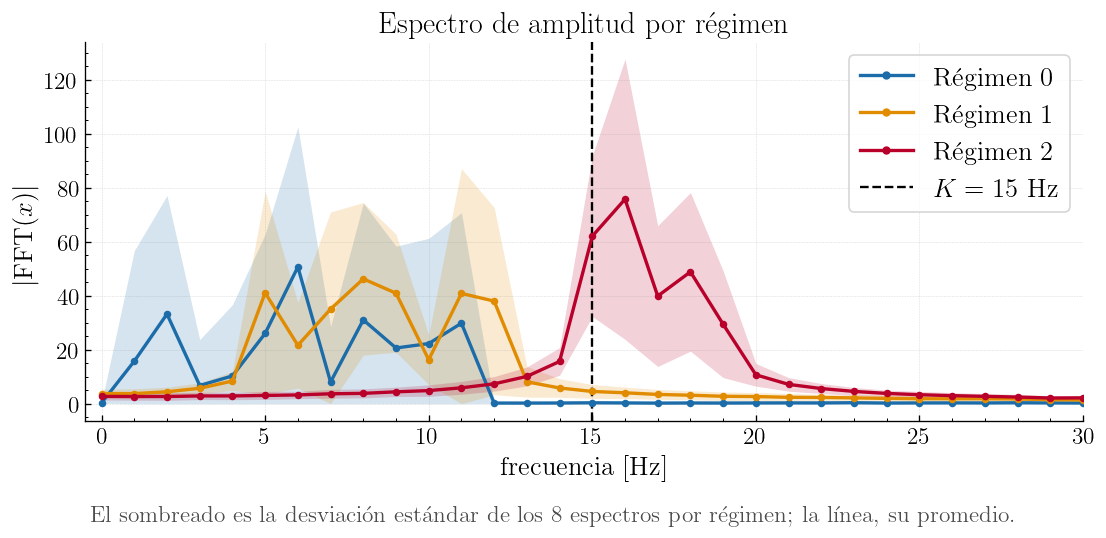

In [60]:
K = 15                                   # número de frecuencias que tendrá la capa Fourier
frecuencias = np.fft.rfftfreq(n_muestras, d=paso_temporal)   # eje de frecuencias de la FFT real [Hz]
banda_visible = frecuencias <= 30        # solo mostramos hasta 30 Hz (ahí está la acción)
f = frecuencias[banda_visible]


fig, ax = plt.subplots(figsize=(9.5, 4.6))
for reg in (0, 1, 2):
    espectros_reg = np.abs(np.fft.rfft(senales[regimenes == reg], axis=1))[:, banda_visible]  # (8, n_freq)
    media = espectros_reg.mean(axis=0)   # espectro promedio del régimen
    desv  = espectros_reg.std(axis=0)    # dispersión señal a señal (desviación estándar)

    # banda sombreada = media ± desviación (variabilidad entre las 8 señales)
    ax.fill_between(f, np.clip(media - desv, 0, None), media + desv,
                    color=COLOR_REG[reg], alpha=0.18, lw=0, zorder=1)
    # espectro PROMEDIO resaltado (línea oscura + marcador por bin de la DFT)
    ax.plot(f, media, color=COLOR_REG[reg], lw=2.0, marker="o", markersize=3.5, zorder=3)



ax.axvline(K, color="k", ls="--", lw=1.4)         # corte de la capa Fourier (K = 15 Hz)
ax.set_xlim(-0.5, 30)
ax.set_xlabel("frecuencia  [Hz]")
ax.set_ylabel(r"$|\mathrm{FFT}(x)|$")
ax.set_title("Espectro de amplitud por régimen")



# Leyenda: color = régimen (la línea con marcadores es el promedio; el sombreado, la desviación)
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=COLOR_REG[r], lw=2.0, marker="o", ms=4,
                  label=f"Régimen {r}") for r in (0, 1, 2)]
handles.append(Line2D([0], [0], color="k", ls="--", lw=1.4, label=r"$K=15$ Hz"))
ax.legend(handles=handles, loc="upper right")


# Pie de página (grande y pegado a la gráfica): qué representa el sombreado
fig.tight_layout(rect=[0, 0.045, 1, 1])
fig.text(0.5, 0.015,
         "El sombreado es la desviación estándar de los 8 espectros por régimen; la línea, su promedio.",
         ha="center", va="bottom", fontsize=14, style="italic", color="0.3")
plt.show()



**Observación:** De esta visualización es interesante concluir que gran parte de los modos de las señales para el **régimen 2** sobrepasan la frecuencia máxima, pues caen entre **15 y 19 Hz**, lo que da pistas de las futuras dificultades que podrá tener la arquitectura escogida para reconstruir las señales de dicho régimen.

# Parte II — La capa Fourier

## 2.1 Construcción de $W_1$
Para cada $k=1,\dots,15$ tomamos dos filas, una para coseno y otra para seno, escaladas por $2/N$, el cual es un factor de la DFT en amplitudes:

$$\bigl(W_1^{\text{Fourier}}\bigr)_{2k-2,\,n}=\tfrac{2}{N}\cos(2\pi k\,t_n),\qquad
\bigl(W_1^{\text{Fourier}}\bigr)_{2k-1,\,n}=\tfrac{2}{N}\sin(2\pi k\,t_n).$$

Sin este factor $W_1 x$ alcanzaría valores $\sim N/2$ y la $\tanh$ se saturaría desde la iteración 0 (gradiente nulo).

Aquí definimos la función `matriz_fourier` que arma esa matriz y construimos `W1_fourier`.

In [61]:
def matriz_fourier(tiempo, K, escala):

    """Construye la matriz de la capa Fourier (2K filas × n_muestras columnas).
    Intercala una fila coseno y una seno por cada frecuencia k = 1..K,
    escaladas por 'escala' (usamos 2/N para reproducir las amplitudes de la DFT)."""

    k_indices = np.arange(1, K + 1)[:, None]                 # frecuencias k = 1..K (columna)
    filas_coseno = escala * np.cos(2 * np.pi * k_indices * tiempo)   # (K, n_muestras)
    filas_seno   = escala * np.sin(2 * np.pi * k_indices * tiempo)   # (K, n_muestras)

    W1 = np.empty((2 * K, tiempo.size))
    W1[0::2] = filas_coseno    # filas pares  -> cosenos
    W1[1::2] = filas_seno      # filas impares -> senos
    
    return W1

# Inicialización de la capa Fourier: W1 con la escala 2/N (amplitudes de la DFT)
W1_fourier = matriz_fourier(tiempo, K, escala=2.0 / n_muestras)
print("W1_fourier shape:", W1_fourier.shape)


W1_fourier shape: (30, 256)


## 2.2 Verificación: $W_1 x$ ES la DFT
Cada par de salidas de la capa Fourier debe coincidir, salvo el signo, con la parte real y la parte imaginaria del coeficiente DFT correspondiente:

$$\bigl(W_1 x\bigr)_{2k-2}=\tfrac{2}{N}\,\mathrm{Re}\,X_k,\qquad
\bigl(W_1 x\bigr)_{2k-1}=-\tfrac{2}{N}\,\mathrm{Im}\,X_k.$$

**En esta celda** tomamos una señal de ejemplo, le aplicamos la capa (`W1_fourier @ x`) y la DFT de NumPy, y comprobamos que coinciden hasta la precisión de máquina.

In [62]:
# Tomamos una señal de ejemplo (la 1ª del régimen 1)
indice_ejemplo = np.where(regimenes == 1)[0][0]
senal_ejemplo  = senales[indice_ejemplo]

salida_capa  = W1_fourier @ senal_ejemplo     # (2K,): lo que produce la capa Fourier
espectro_dft = np.fft.rfft(senal_ejemplo)     # DFT de NumPy (complejo) para comparar

# La capa (escalada 2/N) debe reproducir la parte real y la imaginaria (con signo) de la DFT
real_dft  =  (2.0 / n_muestras) * espectro_dft[1:K+1].real
imag_dft  = -(2.0 / n_muestras) * espectro_dft[1:K+1].imag   # signo: e^{-i2πkt} = cos - i·sin
real_capa = salida_capa[0::2]                  # filas coseno -> parte real
imag_capa = salida_capa[1::2]                  # filas seno   -> parte imaginaria

# Máximo error entre la capa y la DFT (debe ser ~1e-15, precisión de máquina)
err_real = np.max(np.abs(real_capa - real_dft))
err_imag = np.max(np.abs(imag_capa - imag_dft))

print(f"max |Re(W1 x) - (2/N)*Re(DFT)|  = {err_real:.3e}")
print(f"max |Im(W1 x) - (-2/N)*Im(DFT)| = {err_imag:.3e}")
print("-> Coinciden (precisión de máquina): la capa Fourier, en su inicialización,")
print("   ES la DFT en amplitudes.")

max |Re(W1 x) - (2/N)*Re(DFT)|  = 8.674e-16
max |Im(W1 x) - (-2/N)*Im(DFT)| = 7.772e-16
-> Coinciden (precisión de máquina): la capa Fourier, en su inicialización,
   ES la DFT en amplitudes.


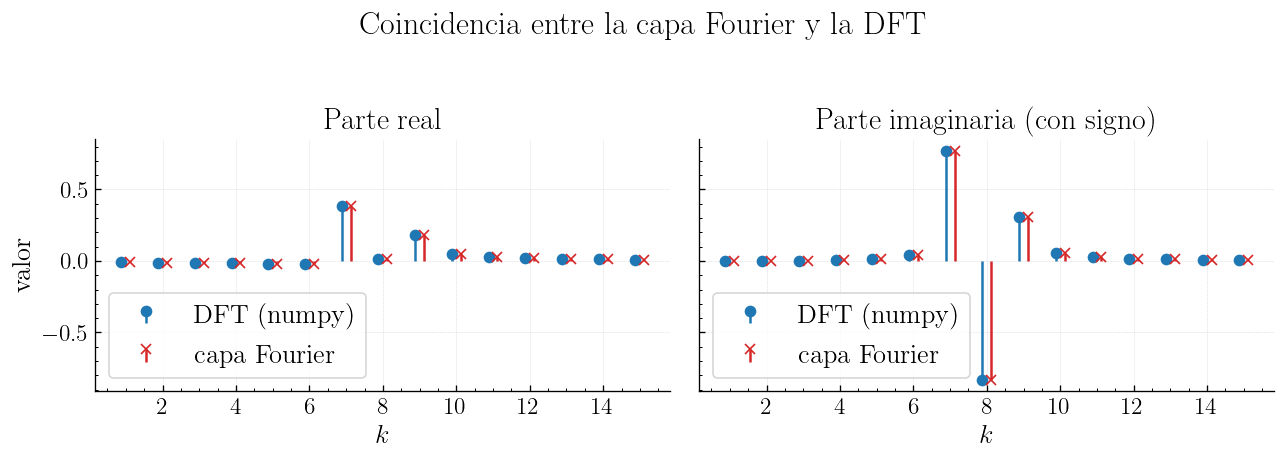

In [63]:
# Comparación visual: coeficientes de la capa (x) vs. los de NumPy (o), parte real e imaginaria
k_indices = np.arange(1, K + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

axes[0].stem(k_indices - 0.12, real_dft, linefmt="C0-", markerfmt="C0o", basefmt=" ",
             label="DFT (numpy)")
axes[0].stem(k_indices + 0.12, real_capa, linefmt="C3-", markerfmt="C3x", basefmt=" ",
             label="capa Fourier")
axes[0].set_title(r"Parte real")
axes[0].set_xlabel(r"$k$")
axes[0].set_ylabel("valor")
axes[0].legend()

axes[1].stem(k_indices - 0.12, imag_dft, linefmt="C0-", markerfmt="C0o", basefmt=" ",
             label="DFT (numpy)")
axes[1].stem(k_indices + 0.12, imag_capa, linefmt="C3-", markerfmt="C3x", basefmt=" ",
             label="capa Fourier")
axes[1].set_title(r"Parte imaginaria (con signo)")
axes[1].set_xlabel(r"$k$")
axes[1].legend()

fig.suptitle("Coincidencia entre la capa Fourier y la DFT", y=1.02)
fig.tight_layout()
plt.show()

# Parte III — La red y el entrenamiento

Construiremos una arquitectura de red neuronal dada por:

$$\hat x = W_2\,\tanh(W_1 x),\qquad W_1\in\mathbb{R}^{2K\times N},\ W_2\in\mathbb{R}^{N\times 2K}.$$

Con una función de pérdida MSE por muestra:

$$\mathcal{L}(W_1,W_2)=\frac1N\|\hat x - x\|^2.$$

**Consideraciones de la arquitectura.**

- *Inicialización de $W_1$:* Fourier (escalada $2/N$) **vs.** aleatoria $\mathcal{N}(0,\sigma^2)$ con $\sigma=\sqrt2/N$ para que sus filas tengan la **misma norma** que las de Fourier.
- *Inicialización de $W_2$:* la misma para ambos modelos, con $\sigma_{W_2}=0.01$. Aquí, $\hat x(0)\approx 0$ y la pérdida inicial es $\approx\mathrm{var}(x)$, con valores idénticos para los dos.
- *Optimizador:* **SGD con momento** ($\beta=0.9$), $\eta=0.05$ — el momento es estándar y necesario para que el SGD converja en 3000 iteraciones con este $\eta$ tan pequeño.
- *Reducción de varianza:* repetimos con **3 semillas** distintas (afectan a $W_2$ y a $W_1^{\text{rand}}$). Reportamos media y dispersión.

Definición de la propagación de la red (`forward`), la pérdida (`loss`), el gradiente compilado `grad_loss = jit(grad(loss))` (backpropagation), un paso de SGD con momento (`paso_sgd`), las dos inicializaciones (`init_fourier`, `init_random`) y el bucle `entrenar`. Los parámetros se guardan como un **pytree** (diccionario `{W1, W2}`) y se actualizan con `jax.tree_util.tree_map`, sin bucles por peso.

In [64]:
# =====================================================================
#  Construcciones JAX
#  - Los parámetros viven en un "pytree", un diccionario {W1, W2}.
#  - grad_loss = jit(grad(loss)) es el backward pass (autodiff en modo reverso), compilado.
#  - Las actualizaciones recorren el pytree con jax.tree_util.tree_map (sin bucles por peso).
# =====================================================================



def forward(params, entradas):

    """Propagación hacia adelante de la red: x_hat = W2 · tanh(W1 · x)."""

    oculta = jnp.tanh(entradas @ params["W1"].T)   # (n, 2K): capa oculta con no linealidad tanh
    return oculta @ params["W2"].T                  # (n, N): reconstrucción de las señales



def loss(params, entradas):

    """Función de pérdida MSE entre la reconstrucción y la señal original: media de (x_hat - x)^2."""

    return jnp.mean((forward(params, entradas) - entradas) ** 2)



# grad_loss: función que calcula el gradiente de loss respecto a params por diferenciación
# automática en modo reverso (backpropagation). jit la compila para que las 3000 iteraciones vuelen.
grad_loss = jit(grad(loss))
loss_jit  = jit(loss)                              # pérdida compilada, para registrar la curva




# ---------- Un paso de SGD con momento (beta=0.9), compilado con @jit --------
# Conservamos el momento: es la decisión de este trabajo para converger en 3000 iteraciones
# con eta=0.05. La actualización usa tree_map aplicada sobre la velocidad del momento,
# en lugar de sobre el gradiente crudo.
@jit
def paso_sgd(params, velocidad, entradas, lr=0.05, beta=0.9):
    grads     = grad_loss(params, entradas)                                          # backward pass
    velocidad = jax.tree_util.tree_map(lambda v, g: beta * v + g, velocidad, grads)  # momento
    params    = jax.tree_util.tree_map(lambda p, v: p - lr * v, params, velocidad)   # p <- p - eta*v
    return params, velocidad


# ---------- Inicializaciones de los pesos (devuelven el pytree {W1, W2}) -----
SIGMA_W1_RANDOM = np.sqrt(2.0) / n_muestras   # iguala la norma de fila de la matriz Fourier
SIGMA_W2        = 0.01                          # pequeño: x_hat(0) ~ 0  ->  L(0) ~ var(x)



def init_fourier(tiempo, K, clave_w2):
    """W1 = matriz de Fourier (escala 2/N); W2 = ruido pequeño (misma clave: comparación justa)."""
    W1 = jnp.asarray(matriz_fourier(np.asarray(tiempo), K, escala=2.0 / tiempo.size))
    W2 = random.normal(clave_w2, (tiempo.size, 2 * K)) * SIGMA_W2
    return {"W1": W1, "W2": W2}



def init_random(n_muestras, K, clave_w1, clave_w2):
    """W1 = ruido con la misma norma de fila que Fourier; W2 = el mismo ruido pequeño."""
    W1 = random.normal(clave_w1, (2 * K, n_muestras)) * SIGMA_W1_RANDOM
    W2 = random.normal(clave_w2, (n_muestras, 2 * K)) * SIGMA_W2
    return {"W1": W1, "W2": W2}



# ---------- Bucle de entrenamiento  ----
def entrenar(params, entradas, n_iter=3000, lr=0.05):
    """SGD con momento; devuelve los pesos finales y el historial de pérdida."""
    velocidad = jax.tree_util.tree_map(jnp.zeros_like, params)   # momento inicial
    historial = np.empty(n_iter)
    for i in range(n_iter):
        params, velocidad = paso_sgd(params, velocidad, entradas, lr=lr)
        historial[i] = float(loss_jit(params, entradas))         # registra L(theta_i)
    return params, historial


## 3.1 Entrenamiento: 3 regímenes × 2 inicializaciones × 3 semillas
3000 iteraciones con $\eta=0.05$. Guardamos toda la historia para analizar la dinámica.

**En esta celda** corremos el experimento completo: para cada semilla y cada régimen entrenamos dos redes (init Fourier y aleatoria, con el mismo $W_2$), guardamos las curvas de pérdida en `resultados` y los pesos finales, e imprimimos un resumen.

In [65]:
N_ITER, LR, N_SEEDS = 3000, 0.05, 3   # iteraciones, learning rate, nº de semillas

# resultados[regimen][init]["loss"] = matriz (N_SEEDS, N_ITER) con la curva de pérdida
resultados = {r: {"fourier": {"loss": np.zeros((N_SEEDS, N_ITER))},
                  "random":  {"loss": np.zeros((N_SEEDS, N_ITER))}}
              for r in (0, 1, 2)}

for s in range(N_SEEDS):
    clave = random.PRNGKey(SEMILLA + s)
    clave_w1_rand, clave_w2 = random.split(clave)   # W2 se comparte entre ambas inicializaciones


    for reg in (0, 1, 2):
        senales_reg = jnp.asarray(senales[regimenes == reg])    # las 8 señales del régimen
        params_fourier = init_fourier(tiempo, K, clave_w2)
        params_random  = init_random(n_muestras, K, clave_w1_rand, clave_w2)

        params_fourier_final, hist_fourier = entrenar(params_fourier, senales_reg, N_ITER, LR)
        params_random_final,  hist_random  = entrenar(params_random,  senales_reg, N_ITER, LR)

        resultados[reg]["fourier"]["loss"][s] = hist_fourier
        resultados[reg]["random"]["loss"][s]  = hist_random


        if s == N_SEEDS - 1:   # guardamos los pesos finales de la última semilla para reconstruir
            resultados[reg]["fourier"]["params_last"] = params_fourier_final
            resultados[reg]["random"]["params_last"]  = params_random_final

# Resumen: pérdida inicial (L0) y final (media sobre semillas) de cada inicialización
print("Resumen (media sobre semillas):")
print(f"{'reg':>3} {'L0':>8} {'L_final_F':>10} {'L_final_R':>10}")


for reg in (0, 1, 2):
    L_inicial       = resultados[reg]["fourier"]["loss"][:, 0].mean()
    L_final_fourier = resultados[reg]["fourier"]["loss"][:, -1].mean()
    L_final_random  = resultados[reg]["random"]["loss"][:, -1].mean()
    print(f"{reg:>3} {L_inicial:>8.4f} {L_final_fourier:>10.2e} {L_final_random:>10.2e}")

Resumen (media sobre semillas):
reg       L0  L_final_F  L_final_R
  0   0.7060   2.28e-13   3.78e-12
  1   0.5726   6.14e-11   2.33e-09
  2   0.6398   3.59e-07   4.51e-07


## 3.2 Evolución de la pérdida
Visualización en **escala logarítmica** de la evolución de la función de pérdida. Aquí, la línea gruesa representa el promedio sobre las 3 semillas y las líneas finas representan las 3 corridas individuales.


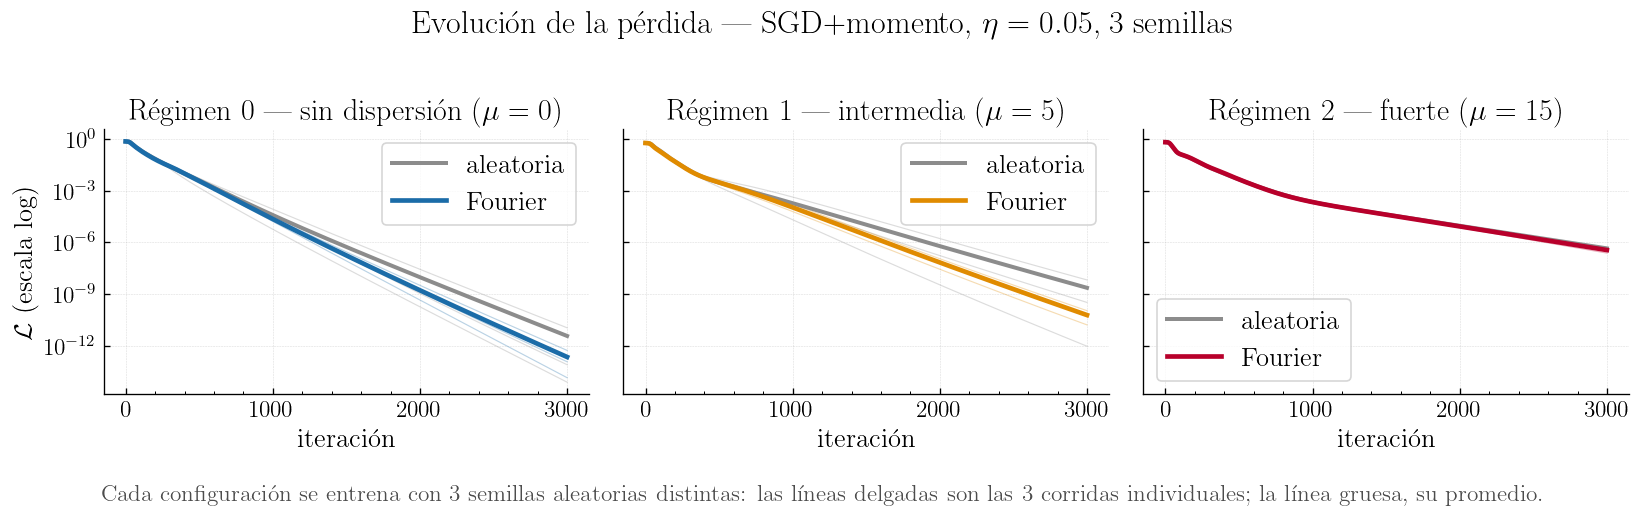

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
iteraciones = np.arange(N_ITER)
for col, reg in enumerate((0, 1, 2)):
    perdidas_fourier = resultados[reg]["fourier"]["loss"]
    perdidas_random  = resultados[reg]["random"]["loss"]
    media_fourier = perdidas_fourier.mean(0)
    media_random  = perdidas_random.mean(0)

    ax = axes[col]
    # las 3 corridas individuales (una por semilla), tenues
    for s in range(N_SEEDS):
        ax.semilogy(iteraciones, perdidas_random[s],  color=COLOR_RANDOM, lw=0.7, alpha=0.30)
        ax.semilogy(iteraciones, perdidas_fourier[s], color=COLOR_REG[reg], lw=0.7, alpha=0.30)
    # promedio sobre las 3 semillas (línea gruesa)
    ax.semilogy(iteraciones, media_random,  color=COLOR_RANDOM, lw=2.4, label="aleatoria")
    ax.semilogy(iteraciones, media_fourier, color=COLOR_REG[reg], lw=2.8, label="Fourier")
    ax.set_title(NOMBRE_REG[reg])
    ax.set_xlabel("iteración")
    ax.legend()

axes[0].set_ylabel(r"$\mathcal{L}$  (escala log)")
fig.suptitle(r"Evolución de la pérdida — SGD+momento, $\eta=0.05$, 3 semillas", y=1.0)
fig.tight_layout(rect=[0, 0.07, 1, 1])
# Pie de página: qué son las líneas finas y las semillas
fig.text(0.5, 0.02,
         "Cada configuración se entrena con 3 semillas aleatorias distintas: las líneas delgadas son "
         "las 3 corridas individuales; la línea gruesa, su promedio.",
         ha="center", va="bottom", fontsize=14, style="italic", color="0.3")
plt.show()


## 3.3 ¿Cuánto más rápido aprende la inicialización Fourier?
Comparamos la pérdida media a iteraciones fijas. `Lrand/Lfourier` $>1$ indica que **Fourier va por delante**.

**En esta celda** imprimimos, por régimen y en varias iteraciones de control, la pérdida media de cada inicialización y su cociente.

In [67]:
print(f"{'reg':>3} {'iter':>6} {'L_fourier':>11} {'L_random':>11} {'Lrand/Lfour':>14}")

for reg in (0, 1, 2):

    media_fourier = resultados[reg]["fourier"]["loss"].mean(0)
    media_random  = resultados[reg]["random"]["loss"].mean(0)

    for iter_control in (50, 100, 200, 500, 1500):
        lf = media_fourier[iter_control - 1]
        lr = media_random[iter_control - 1]

        print(f"{reg:>3} {iter_control:>6} {lf:>11.5f} {lr:>11.5f} {lr/lf:>14.3f}")
        
    print()

reg   iter   L_fourier    L_random    Lrand/Lfour
  0     50     0.44657     0.47449          1.063
  0    100     0.21576     0.22656          1.050
  0    200     0.06547     0.07053          1.077
  0    500     0.00363     0.00392          1.079
  0   1500     0.00000     0.00000          3.109

  1     50     0.38644     0.41925          1.085
  1    100     0.18596     0.20345          1.094
  1    200     0.04864     0.04969          1.022
  1    500     0.00300     0.00294          0.980
  1   1500     0.00000     0.00001          4.011

  2     50     0.34349     0.33851          0.985
  2    100     0.13186     0.13115          0.995
  2    200     0.05908     0.05832          0.987
  2    500     0.00452     0.00447          0.990
  2   1500     0.00004     0.00004          1.024



## 3.4 Reconstrucción cualitativa

Aquí visualizaremos una señal de cada régimen y su reconstrucción tras 3000 iteraciones.

Definimos una función de reconstrucción, `reconstruir`, la cual consume una señal y la pasa por la red entrenada, y graficamos, por régimen, la señal original con las dos reconstrucciones, Fourier y aleatoria, encima, anotando su RMSE.

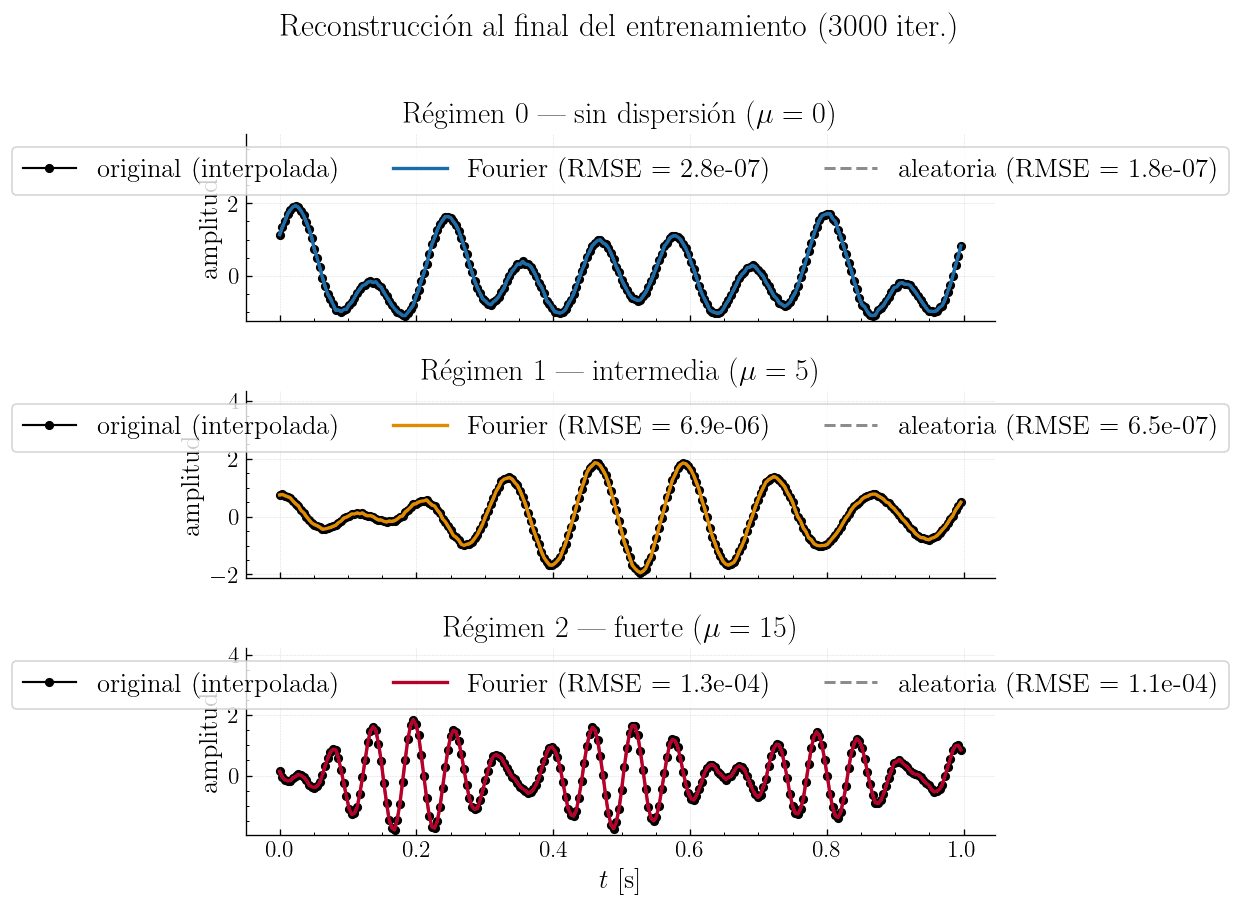

In [68]:
def reconstruir(reg, indice_local):

    """Devuelve (señal original, reconstrucción Fourier, reconstrucción aleatoria)
    para la señal 'indice_local'-ésima del régimen dado, usando los pesos finales."""

    indice_global = np.where(regimenes == reg)[0][indice_local]
    senal = senales[indice_global]

    recon_fourier = np.asarray(forward(resultados[reg]["fourier"]["params_last"], jnp.asarray(senal[None, :])))[0]
    recon_random  = np.asarray(forward(resultados[reg]["random"]["params_last"], jnp.asarray(senal[None, :])))[0]
    
    return senal, recon_fourier, recon_random

fig, axes = plt.subplots(3, 1, figsize=(9.5, 7.6), sharex=True)

for ax, reg in zip(axes, (0, 1, 2)):

    senal, recon_fourier, recon_random = reconstruir(reg, 0)
    rmse_fourier = np.sqrt(np.mean((senal - recon_fourier) ** 2))
    rmse_random  = np.sqrt(np.mean((senal - recon_random) ** 2))


    dibujar_original(ax, tiempo, senal)   # original: puntos + interpolación, al fondo
    ax.plot(tiempo, recon_fourier, "-", color=COLOR_REG[reg], lw=2.0, zorder=3,label=fr"Fourier (RMSE $=$ {rmse_fourier:.1e})")
    ax.plot(tiempo, recon_random, "--", color=COLOR_RANDOM, lw=1.8, zorder=2, label=fr"aleatoria (RMSE $=$ {rmse_random:.1e})")
    ax.set_ylabel("amplitud")
    ax.set_title(NOMBRE_REG[reg])


    # dejamos espacio arriba para que la leyenda no pise las ondas
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi + 0.55 * (hi - lo))
    ax.legend(loc="upper center", ncol=3)


axes[-1].set_xlabel(r"$t$  [s]")

fig.suptitle(f"Reconstrucción al final del entrenamiento ({N_ITER} iter.)", y=1.0)
fig.tight_layout()
plt.show()

## 3.5 Resumen cuantitativo de la reconstrucción
La figura anterior muestra una señal por régimen. Aquí promediamos el RMSE de reconstrucción sobre **las 8 señales** de cada régimen (última semilla), para confirmar que ambas inicializaciones reconstruyen bien y cuantificar la diferencia final.

Calculamos, para cada inicialización y régimen, el RMSE medio (± desviación) sobre las 8 señales.

In [69]:
def rmse_por_regimen(clave_init):
    """RMSE de reconstrucción (media y desviación sobre las 8 señales) por régimen,
    para la inicialización indicada ('fourier' o 'random')."""
    filas = []
    for reg in (0, 1, 2):
        senales_reg = senales[regimenes == reg]
        recon = np.asarray(forward(resultados[reg][clave_init]["params_last"],
                                    jnp.asarray(senales_reg)))
        rmse = np.sqrt(((recon - senales_reg) ** 2).mean(axis=1))   # un RMSE por señal
        filas.append((reg, rmse.mean(), rmse.std()))
    return filas

print(f"{'reg':>3} {'RMSE_fourier':>16} {'RMSE_aleatoria':>16}")
for (reg, media_f, std_f), (_, media_r, std_r) in zip(rmse_por_regimen("fourier"),
                                                      rmse_por_regimen("random")):
    print(f"{reg:>3} {media_f:>10.2e}±{std_f:.0e} {media_r:>10.2e}±{std_r:.0e}")

reg     RMSE_fourier   RMSE_aleatoria
  0   5.94e-07±4e-07   2.33e-07±2e-07
  1   8.61e-06±6e-06   7.69e-07±6e-07
  2   5.47e-04±4e-04   5.31e-04±4e-04


# Parte IV — Análisis de compresión

Para cada señal calculamos su espectro DFT y miramos cuántos coeficientes acumulan el **95 % de la energía**:

$$E_k = |X_k|^2,\quad \text{menor }k_{95}\text{ tal que }\sum_{j\text{ entre los }k_{95}\text{ mayores}}E_j\geq 0.95\sum_j E_j.$$

Si "pocos" modos bastan, la base de Fourier es **eficiente** para representar la señal.

Definimos `modos_para_95` (cuántos modos DFT acumulan el 95 % de la energía de una señal) y resumimos ese número por régimen.

In [70]:
def modos_para_95(senal):

    """Devuelve (nº de modos DFT para el 95% de la energía, curva de energía acumulada).
    Ordena los modos de mayor a menor energía e ignora la componente DC (k=0)."""

    espectro = np.fft.rfft(senal)
    energia = np.abs(espectro) ** 2
    energia[0] = 0.0                                  # ignoramos la componente continua (DC)
    orden_desc = np.argsort(energia)[::-1]            # modos de mayor a menor energía
    acumulada = np.cumsum(energia[orden_desc]) / energia[orden_desc].sum()
    n_modos = int(np.searchsorted(acumulada, 0.95) + 1)

    return n_modos, acumulada


# Nº de modos necesarios por señal, agrupado por régimen
conteo_por_regimen = {r: [] for r in (0, 1, 2)}

for i in range(senales.shape[0]):
    n_modos, _ = modos_para_95(senales[i])
    conteo_por_regimen[int(regimenes[i])].append(n_modos)

print("Modos DFT necesarios para 95% de la energía:")

for reg in (0, 1, 2):
    modos = np.asarray(conteo_por_regimen[reg])
    
    print(f"  régimen {reg}: media={modos.mean():.1f}  std={modos.std():.1f} "f"min={modos.min()}  max={modos.max()}")

Modos DFT necesarios para 95% de la energía:
  régimen 0: media=3.0  std=0.0 min=3  max=3
  régimen 1: media=5.6  std=1.9 min=3  max=9
  régimen 2: media=6.2  std=3.6 min=2  max=14


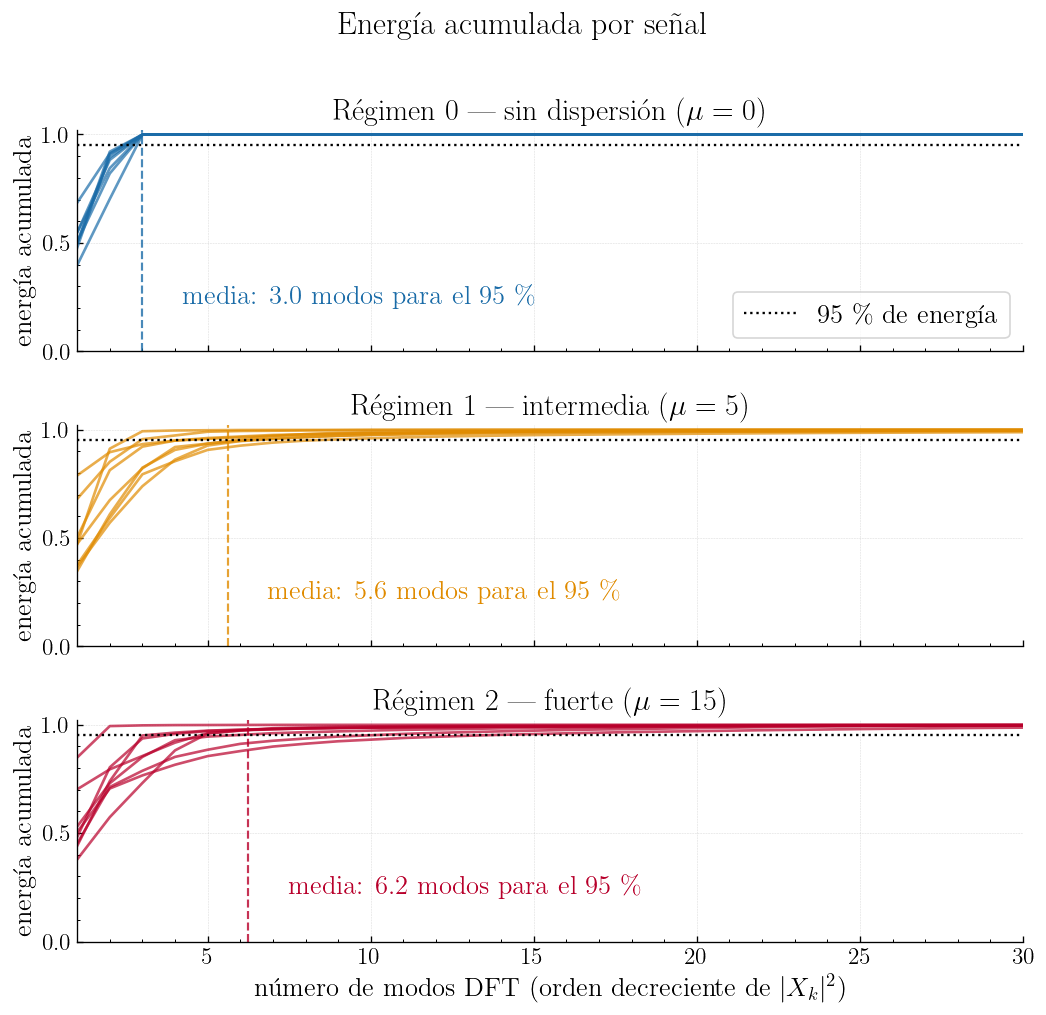

In [71]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True, sharey=True)

for ax, reg in zip(axes, (0, 1, 2)):

    modos_reg = []

    for i in np.where(regimenes == reg)[0]:

        n_modos, acumulada = modos_para_95(senales[i])
        ax.plot(np.arange(1, len(acumulada) + 1), acumulada, color=COLOR_REG[reg], lw=1.6, alpha=0.7)
        modos_reg.append(n_modos)

    media_modos = float(np.mean(modos_reg))

    ax.axhline(0.95, color="k", ls=":", lw=1.4)                       # umbral del 95 %
    ax.axvline(media_modos, color=COLOR_REG[reg], ls="--", lw=1.3, alpha=0.8)  # promedio de modos
    ax.annotate(fr"media: {media_modos:.1f} modos para el 95 \%",
                xy=(media_modos, 0.30), xytext=(media_modos + 1.2, 0.22),
                color=COLOR_REG[reg])
    ax.set_ylim(0, 1.02)
    ax.set_ylabel("energía acumulada")
    ax.set_title(NOMBRE_REG[reg])


axes[0].set_xlim(1, 30)
axes[-1].set_xlabel(r"número de modos DFT (orden decreciente de $|X_k|^2$)")

from matplotlib.lines import Line2D

axes[0].legend(handles=[Line2D([0], [0], color="k", ls=":", lw=1.4, label=r"95 \% de energía")],
               loc="lower right")

fig.suptitle("Energía acumulada por señal", y=1.0)
fig.tight_layout()
plt.show()

## 4.1 Reconstrucción truncada con los $K=15$ modos más fuertes
Reconstruimos cada señal con sólo los 15 modos DFT más energéticos y medimos el error relativo.

**En esta celda** definimos `reconstruir_truncado` , una función que mantiene solo los K modos más fuertes y aplica la DFT inversa, y comparamos, por régimen, la señal original con su versión truncada, anotando el error relativo.

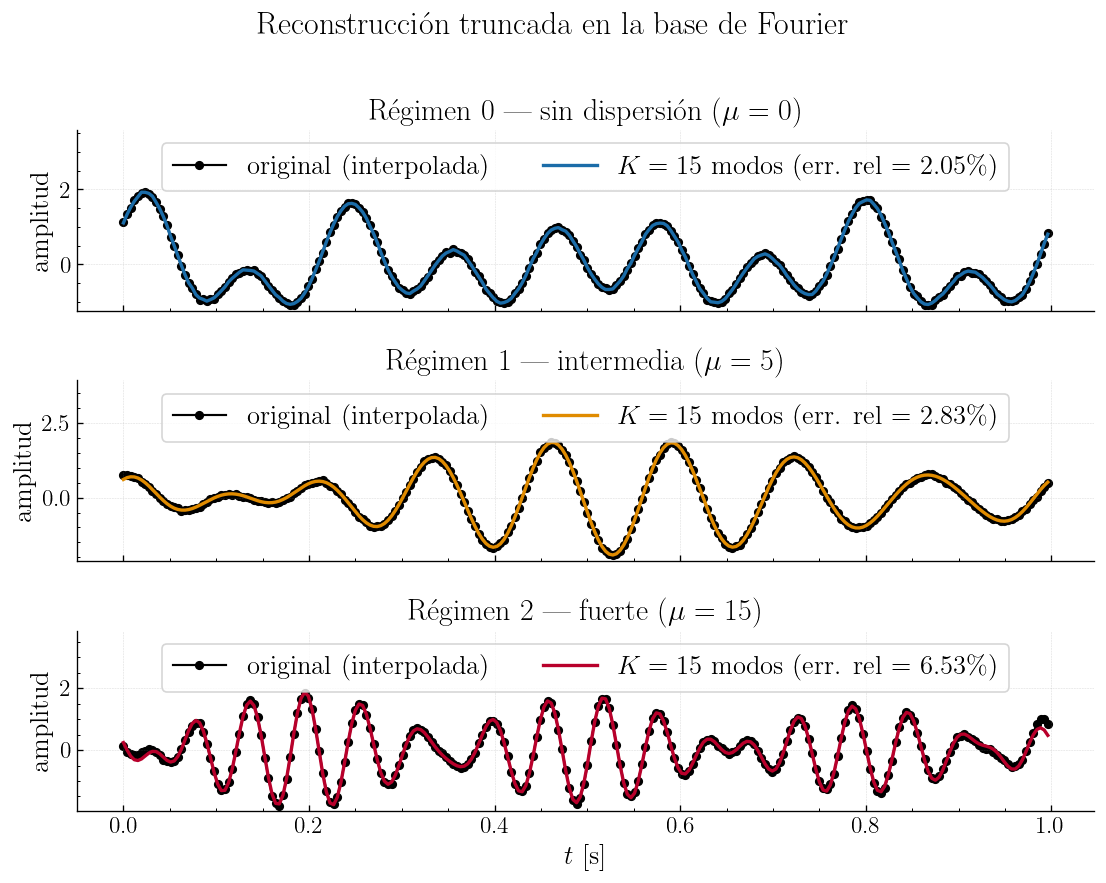

In [72]:
def reconstruir_truncado(senal, K_mantener=15):

    """Reconstruye la señal usando solo los 'K_mantener' modos DFT más energéticos."""

    espectro = np.fft.rfft(senal)
    energia = np.abs(espectro) ** 2
    energia[0] = 0.0                                       # ignoramos DC al elegir modos
    top_modos = np.argsort(energia)[::-1][:K_mantener]     # índices de los K modos más fuertes
    espectro_truncado = np.zeros_like(espectro)
    espectro_truncado[top_modos] = espectro[top_modos]

    return np.fft.irfft(espectro_truncado, n=senal.size), top_modos

fig, axes = plt.subplots(3, 1, figsize=(9.5, 7.4), sharex=True)

for ax, reg in zip(axes, (0, 1, 2)):

    indice = np.where(regimenes == reg)[0][0]
    senal = senales[indice]
    recon_truncada, _ = reconstruir_truncado(senal, K_mantener=K)
    err_relativo = np.linalg.norm(senal - recon_truncada) / np.linalg.norm(senal)

    dibujar_original(ax, tiempo, senal)   # original: puntos + interpolación, al fondo

    ax.plot(tiempo, recon_truncada, "-", color=COLOR_REG[reg], lw=2.0, zorder=3,
            label=fr"$K={K}$ modos (err. rel $=$ {err_relativo*100:.2f}\%)")
    ax.set_title(NOMBRE_REG[reg])
    ax.set_ylabel("amplitud")
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi + 0.45 * (hi - lo))
    ax.legend(loc="upper center", ncol=2)

axes[-1].set_xlabel(r"$t$  [s]")

fig.suptitle("Reconstrucción truncada en la base de Fourier", y=1.0)
fig.tight_layout()
plt.show()

# Parte V — Aprendizaje en el espacio de frecuencias - Experimento independiente

Hasta aquí la red se entrenó comparando su salida con la **señal original**. 
Ahora se propone un experimento que nace de la curiosidad de entender la Transformada de Fourier y su capacidad de traducir entre el dominio del tiempo y el dominio de frecuencias.

En este experimento independiente a lo pedido exploramos la pregunta: ¿Qué pasa si comparamos la salida de la red neuronal con el espectro de la DFT?

Para realizar este experimento se hacen las siguientes consideraciones:

- Inicializamos $W_1$ con la **matriz de Fourier**, tal y como se realizó en la Parte III.
- Actualizamos la función de pérdida para que sea una MSE que mide contra la **transformada de Fourier** $\Phi x$ de la señal original.
- Para evaluar, tomamos la salida $\hat y$ de la red y la llevamos de vuelta al tiempo con la **transformada inversa** $\hat x = \Phi^\top \hat y$, y la comparamos con la señal original $x$.

Esta construcción permite a la red aprender **dentro del espacio de frecuencias**, y sus valores de salida $\hat y$ son precisamente el espectro de la señal correspondiente.
Aquí buscamos ver si existe alguna diferencia entre entrenar dentro del dominio temporal o dentro del dominio de frecuencias.

Las consideraciones previas nos llevan a una arquitectura dada por:

$$\mathcal{L}_{\text{freq}}(W_1,W_2)=\frac1N\bigl\lVert\, \hat y - \Phi x\,\bigr\rVert^2,
\qquad \hat y = W_2\tanh(W_1 x),\qquad \hat x = \Phi^\top\hat y .$$

Donde $\Phi$ será una **matriz de Fourier real ortonormal** (256×256) que servirá de transformada. Sus filas son la versión *completa y normalizada* de las mismas $\cos/\sin$ que forman $W_1$. 

## 5.1 Construcción y verificación de la transformada $\Phi$

In [73]:
def matriz_fourier_ortonormal(N):
    # Base de Fourier real ortonormal (N filas): DC, pares cos/sin, Nyquist

    n = np.arange(N)
    filas = [np.ones(N) / np.sqrt(N)]                       # término DC (k=0)

    for k in range(1, N // 2):
        filas.append(np.sqrt(2/N) * np.cos(2*np.pi*k*n/N))
        filas.append(np.sqrt(2/N) * np.sin(2*np.pi*k*n/N))

    filas.append(np.cos(np.pi*n) / np.sqrt(N))             # Nyquist (k=N/2)
    return np.array(filas)

Phi   = matriz_fourier_ortonormal(n_muestras)
Phi_j = jnp.asarray(Phi)

x0 = senales[0]

print("Phi shape:", Phi.shape)
print(f"ortonormal:      max|Phi Phi^T - I|   = {np.max(np.abs(Phi @ Phi.T - np.eye(n_muestras))):.2e}")
print(f"inversa exacta:  max|Phi^T Phi x - x| = {np.max(np.abs(Phi.T @ (Phi @ x0) - x0)):.2e}")

Phi shape: (256, 256)
ortonormal:      max|Phi Phi^T - I|   = 1.72e-14
inversa exacta:  max|Phi^T Phi x - x| = 3.23e-14


## 5.2 Entrenamiento en el espacio de frecuencias
Misma arquitectura e init Fourier que la Parte III, mismo $W_2$ compartido, mismo optimizador (SGD+momento, $\eta=0.05$, 3000 iter, 3 semillas). Lo único que cambia es el **objetivo** ($\Phi x$ en vez de $x$). Durante el entrenamiento medimos el **error de reconstrucción en el tiempo**, $\tfrac1N\lVert\Phi^\top\hat y - x\rVert^2$.

In [74]:
def loss_freq(params, X, Xf):

    """MSE en el ESPACIO DE FRECUENCIAS: comparamos el espectro producido con Phi·x."""

    return jnp.mean((forward(params, X) - Xf) ** 2)

@jit
def paso_freq(params, vel, X, Xf, lr=0.05, beta=0.9):

    val, grads = value_and_grad(loss_freq)(params, X, Xf)
    vel    = jax.tree_util.tree_map(lambda v, g: beta * v + g, vel, grads)   # momento (pytree)
    params = jax.tree_util.tree_map(lambda p, v: p - lr * v, params, vel)    # p <- p - eta*v

    return params, vel, val

@jit
def recon_mse(params, X):

    # error en el TIEMPO del modelo-frecuencia: x_hat = Phi^T y_hat
    xhat = forward(params, X) @ Phi_j

    return jnp.mean((xhat - X) ** 2)

res_freq = {r: {"recon": np.zeros((N_SEEDS, N_ITER))} for r in (0, 1, 2)}

for s in range(N_SEEDS):
    key = random.PRNGKey(SEMILLA + s)
    _, key_w2 = random.split(key)                 # mismo W2 que el modelo Fourier (Parte III)

    for reg in (0, 1, 2):

        Xr = jnp.asarray(senales[regimenes == reg])
        Xf = Xr @ Phi_j.T                          # objetivo en frecuencia = Phi x
        params = init_fourier(tiempo, K, key_w2)
        vel = jax.tree_util.tree_map(jnp.zeros_like, params)   # momento inicial (pytree de ceros)

        for i in range(N_ITER):

            params, vel, _ = paso_freq(params, vel, Xr, Xf)
            res_freq[reg]["recon"][s, i] = float(recon_mse(params, Xr))

        if s == N_SEEDS - 1:
            res_freq[reg]["params_last"] = params

print("Error de reconstrucción final (media sobre semillas):")

for reg in (0, 1, 2):

    print(f"  régimen {reg}:  freq-train = {res_freq[reg]['recon'][:, -1].mean():.2e} "f"señal-train (Parte III) = {resultados[reg]['fourier']['loss'][:, -1].mean():.2e}")


Error de reconstrucción final (media sobre semillas):
  régimen 0:  freq-train = 8.20e-14 señal-train (Parte III) = 2.28e-13
  régimen 1:  freq-train = 6.90e-10 señal-train (Parte III) = 6.14e-11
  régimen 2:  freq-train = 9.53e-07 señal-train (Parte III) = 3.59e-07


## 5.3 Comprobación del aprendizaje del espectro
Aquí confirmaremos si en efecto la red neuronal entrenada en el espacio de frecuencias es capaz de reconstruir la señal en ambos dominios.
Izquierda: la reconstrucción $\hat x=\Phi^\top\hat y$ sobre la señal original. Derecha: el espectro aprendido $\hat y$ frente al espectro real $\Phi x$ (primeros coeficientes, donde vive la energía).

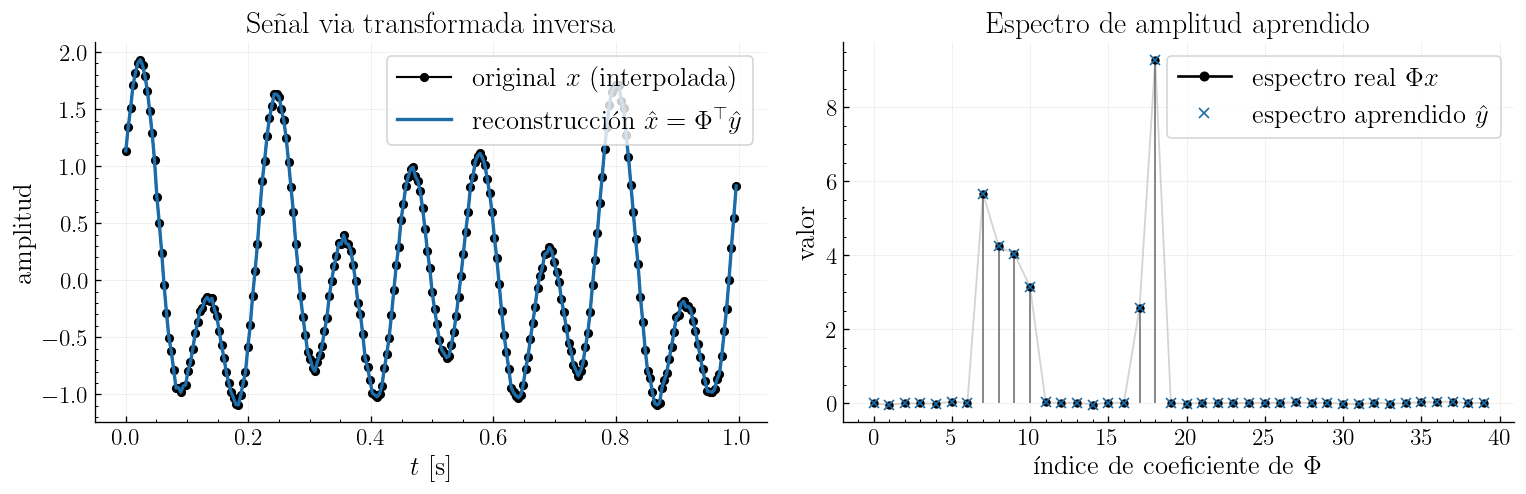

In [75]:
reg = 0
p   = res_freq[reg]["params_last"]
idx = np.where(regimenes == reg)[0][0]
x   = senales[idx]
yhat   = np.asarray(forward(p, jnp.asarray(x[None, :])))[0]   # espectro aprendido
xhat   = yhat @ Phi                                           # reconstrucción (inversa)
target = Phi @ x                                             # espectro real

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

dibujar_original(axes[0], tiempo, x, label=r"original  $x$ (interpolada)")

axes[0].plot(tiempo, xhat, "-", color=COLOR_REG[reg], lw=2.0, zorder=3,
             label=r"reconstrucción  $\hat x=\Phi^\top\hat y$")
axes[0].set_xlabel(r"$t$  [s]")
axes[0].set_ylabel("amplitud")
axes[0].set_title("Señal via transformada inversa")
axes[0].legend(loc="upper right")

m = 40
coef = np.arange(m)

# espectro real como stem (discreto); espectro aprendido como marcadores encima
# silueta tenue del espectro real (recta entre puntos, por detrás)

axes[1].plot(coef, target[:m], color="0.45", lw=1.1, alpha=0.30, zorder=1)

ml, sl, bl = axes[1].stem(coef, target[:m], basefmt=" ")
plt.setp(sl, color="0.45", lw=1.0)
plt.setp(ml, color="k", markersize=4)

axes[1].plot(coef, yhat[:m], marker="x", linestyle="none", markersize=5.5,
             color=COLOR_REG[reg])
axes[1].set_xlabel(r"índice de coeficiente de $\Phi$")
axes[1].set_ylabel("valor")
axes[1].set_title("Espectro de amplitud aprendido")
from matplotlib.lines import Line2D

h_esp = [Line2D([0], [0], color="k", lw=1.6, marker="o", ms=5,
                label=r"espectro real  $\Phi x$"),
         Line2D([0], [0], color=COLOR_REG[reg], lw=0, marker="x", ms=6,
                label=r"espectro aprendido  $\hat y$")]
axes[1].legend(handles=h_esp, loc="upper right")
fig.tight_layout()
plt.show()

## 5.4 Comparación de las reconstrucciones en frecuencia y en el tiempo.
Comparamos el **error de reconstrucción de la señal** de los dos modelos donde se inicializó la primera capa con Fourier, aquel donde se entrenó con la pérdida en frecuencia y el otro con la pérdida en el tiempo.

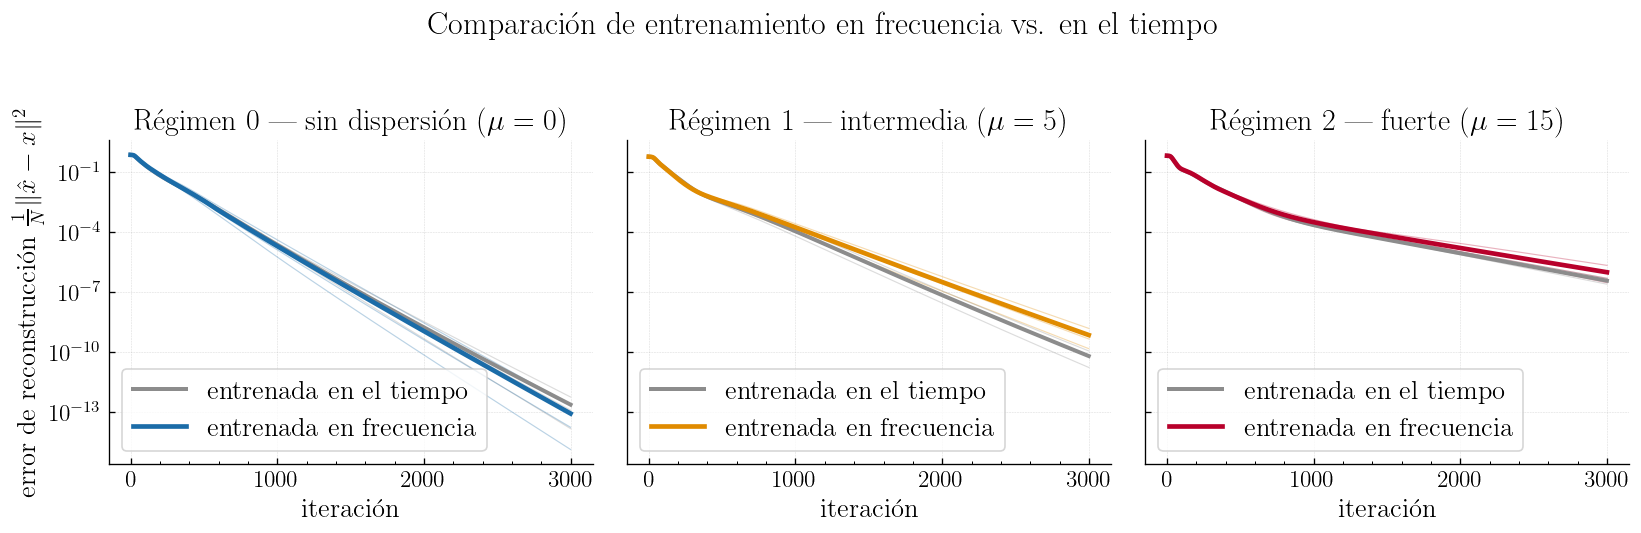

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)

it = np.arange(N_ITER)

for ax, reg in zip(axes, (0, 1, 2)):

    RF = res_freq[reg]["recon"];             mF = RF.mean(0)
    RS = resultados[reg]["fourier"]["loss"]; mS = RS.mean(0)

    for s in range(N_SEEDS):

        ax.semilogy(it, RS[s], color=COLOR_RANDOM, lw=0.7, alpha=0.30)
        ax.semilogy(it, RF[s], color=COLOR_REG[reg], lw=0.7, alpha=0.30)

    ax.semilogy(it, mS, color=COLOR_RANDOM, lw=2.4, label="entrenada en el tiempo")
    ax.semilogy(it, mF, color=COLOR_REG[reg], lw=2.8, label="entrenada en frecuencia")
    ax.set_title(NOMBRE_REG[reg])
    ax.set_xlabel("iteración")
    ax.legend()

axes[0].set_ylabel(r"error de reconstrucción $\frac{1}{N}\|\hat x-x\|^2$")

fig.suptitle("Comparación de entrenamiento en frecuencia vs. en el tiempo", y=1.02)
fig.tight_layout()
plt.show()

## 5.5 ¿Hubo diferencia?: Relación de Parseval
Con $\Phi$ ortonormal, el error en frecuencia y el error de reconstrucción en el tiempo son **la misma cantidad**:

$$\lVert\Phi^\top\hat y - x\rVert^2=\lVert\Phi^\top(\hat y-\Phi x)\rVert^2=\lVert\hat y-\Phi x\rVert^2=N\,\mathcal{L}_{\text{freq}}.$$

Lo verificamos numéricamente en los pesos finales:

In [77]:
reg = 0

p   = res_freq[reg]["params_last"]
Xr  = jnp.asarray(senales[regimenes == reg])
Xf  = Xr @ Phi_j.T

L_freq  = float(jnp.mean((forward(p, Xr) - Xf) ** 2))          # error en frecuencia
L_recon = float(jnp.mean((forward(p, Xr) @ Phi_j - Xr) ** 2))  # error en el tiempo

print(f"L_freq (en frecuencia)      = {L_freq:.6e}")
print(f"L_recon (en el tiempo)      = {L_recon:.6e}")
print(f"|L_freq - L_recon|          = {abs(L_freq - L_recon):.2e}   -> idénticos (debido a Parseval)")

L_freq (en frecuencia)      = 1.686266e-14
L_recon (en el tiempo)      = 1.686266e-14
|L_freq - L_recon|          = 2.56e-23   -> idénticos (debido a Parseval)


## 5.6 Lectura del experimento
Entrenar la red para reconstruir el **espectro** $\Phi x$ y luego invertir reconstruye la señal igual de bien que entrenar directamente en el tiempo, lo cual se debe a la relación de Parseval, quien garantiza, por la ortonormalidad de $\Phi$, que el error en frecuencia y el error en el tiempo son la misma cantidad numérica. Luego, el proceso y velocidad de entrenamiento no se ve afectado; y el objeto al que la red neuronal tiende es exactamente igual, tanto en tiempo como en frecuencia, debido a la conocida relación de dualidad que la Transformada de Fourier establece entre estos dominios. 

# Parte VI — Conclusiones

1. **La capa $W_1$ en su inicialización Fourier es exactamente la DFT** de la señal (parte real y parte imaginaria con signo), salvo el factor $2/N$ — verificado con error $\sim 10^{-15}$.

2. **Compresión.** Casi todas las señales necesitan **3–9 modos DFT** para acumular el 95 % de la energía. Es decir, $K=15$ es más que suficiente *en número de coeficientes*… **siempre que esas frecuencias estén dentro de la banda** $1\le k\le 15$.

3. **Régimen 0 — la base Fourier ayuda.** Las señales viven en frecuencias $1\le f\le 11$ Hz, exactamente donde apunta la base. A iteraciones tempranas (50, 100, 200) la pérdida media de la inicialización aleatoria es **5–9 % más alta** que la de Fourier, de forma consistente sobre las 3 semillas.

4. **Régimen 1 — Fourier sigue por delante.** Las frecuencias (5–12 Hz) siguen dentro de la base; la ventaja temprana es similar a la del régimen 0.

5. **Régimen 2 — la base Fourier ya *no* ayuda.** Los picos espectrales están entre **15 y 19 Hz**, *justo en o por encima* del corte $K=15$. Las dos inicializaciones se comportan esencialmente igual.

6. **Magnitudes esperables.** Como $W_1$ también se entrena, las dos inicializaciones acaban convergiendo a pérdidas muy parecidas; el "head-start" de Fourier sólo se nota en la **velocidad inicial**. Si $W_1$ estuviera *congelada* la diferencia sería mucho mayor.

7. **Aprender en frecuencia (Parte V).** Entrenar la red para reproducir el **espectro** $\Phi x$ y reconstruir con la transformada inversa da el mismo resultado que entrenar en el tiempo. Por **Parseval** (con $\Phi$ ortonormal) ambos errores son idénticos: la base de Fourier define un espacio de trabajo equivalente al del tiempo para esta tarea.

**Respuesta a la pregunta guía.** Arrancar en la base "correcta" (Fourier) **sí ayuda**, *pero sólo cuando "correcta" es realmente correcta*: las señales deben caber en la banda de frecuencias que la base cubre. El experimento muestra el caso ideal (régimen 0) y el contraejemplo (régimen 2), evidencia de que la elección de la base inicial es una decisión informada por el dominio, no una receta universal.